# Sigmoid aperture validation
This notebook ensures the `SigmoidAperture` component attenuates a Gaussian beam correctly by comparing the analytic Gaussian-beam propagation pipeline against a direct Fresnel-FFT simulation with the same transmission mask.

In [97]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from temgym_core.gaussian import SigmoidAperture, circular_input_wave, run_to_end_vmapped, KrivanekLens
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.components import Detector
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.constants import energy2wavelength

jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [98]:
shape = (256, 256)
pixel_size = (5e-6, 5e-6)
voltage = 200e3
waist = 5e-6
radius = 0.2e-3
edge_width = 1e-12
sharpness = 1e14
z_aperture = 0.04
z_detector = 0.04
wavelength = float(energy2wavelength(voltage))

det_aperture = Detector(z=z_aperture, pixel_size=pixel_size, shape=shape)
det_output = Detector(z=z_detector, pixel_size=pixel_size, shape=shape)
aperture = SigmoidAperture(
    z=z_aperture,
    radius=radius,
    edge_width=edge_width,
    sharpness=sharpness,
    t_low=0.00,
    t_high=1.0,
)
aberration_coefficients = KrivanekCoeffs(
    C12=1e-2,
    C23=5e2,
    C32=1e3,
    C34=1e5,
    C43=5e6,
)
aberrated_lens = KrivanekLens(z=z_aperture, focal_length=5, coeffs=aberration_coefficients)

rays_in = circular_input_wave(aperture_radius = radius,
                              waist=waist,
                              voltage=voltage)

print(f"Number of rays: {len(rays_in.x)}")

Number of rays: 20107


In [99]:
rays_out = run_to_end_vmapped(rays_in, (aperture, aberrated_lens, det_output))
field_in = evaluate_gaussians_gpu_kernel_wrapper(rays_in, det_output)
field_out = evaluate_gaussians_gpu_kernel_wrapper(rays_out, det_output).block_until_ready()

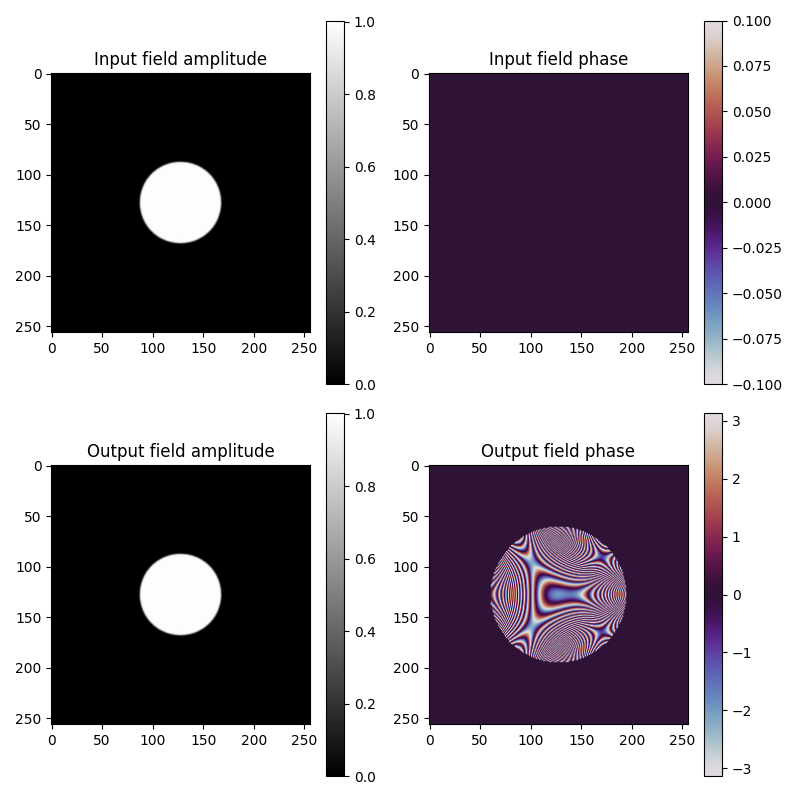

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Amplitude of input field
im0 = axes[0, 0].imshow(jnp.abs(field_in), cmap="gray")
axes[0, 0].set_title("Input field amplitude")
fig.colorbar(im0, ax=axes[0, 0])

# Phase of input field
im1 = axes[0, 1].imshow(jnp.angle(field_in), cmap="twilight")
axes[0, 1].set_title("Input field phase")
fig.colorbar(im1, ax=axes[0, 1])

# Amplitude of output field
im2 = axes[1, 0].imshow(jnp.abs(field_out), cmap="gray")
axes[1, 0].set_title("Output field amplitude")
fig.colorbar(im2, ax=axes[1, 0])

# Phase of output field
im3 = axes[1, 1].imshow(jnp.angle(field_out), cmap="twilight")
axes[1, 1].set_title("Output field phase")
fig.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()